# Non-Stationary GEVD: Neural ODE on μ(t)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/evt_nonstat_neural_ode.ipynb)

The previous two notebooks parameterised $\mu(t)$ as a *function* — first linear, then a B-spline basis expansion. This notebook takes the dynamical-systems route: $\mu(t)$ is the *state of a learned ODE*,

$$
\frac{d\mu}{dt} \;=\; f_\theta\bigl(\mu(t), t\bigr), \qquad \mu(0) = \mu_0,
$$

where $f_\theta$ is a small multilayer perceptron (the neural-ODE setup of Chen, Rubanova, Bettencourt & Duvenaud, NeurIPS 2018). Solving the ODE on the data times yields $\mu(t_i)$; gradient descent through `diffrax.diffeqsolve` trains $\theta$ jointly with the stationary $(\sigma, \xi)$ to maximise the GEVD log-likelihood.

Why bother with this when P-splines already work? Two reasons:

1. **Smoothness for free.** A neural ODE produces $C^1$ trajectories without any hand-tuned smoothness penalty.
2. **Generalisation to coupled systems.** The 1D scalar case here is the building block; the same recipe extends to multi-dimensional latent states (think: temperature + humidity coupled), to control inputs (forcings), and to stochastic ODEs.

**What we cover**

1. **Theory.** The neural ODE; differentiable adaptive ODE solvers; the gradient through `diffrax`.
2. **Synthetic data with a non-monotone trend.** A sinusoidal-plus-linear $\mu(t)$ that neither linear regression nor a 2-knot spline can capture cleanly.
3. **Model.** A 1-state neural ODE with a small MLP vector field; `diffrax.diffeqsolve` integrating from $t = 0$ to $t = T$ and saving at the data times.
4. **Training.** `optax.adam` on the negative GEVD log-likelihood.
5. **Diagnostics.** Recovery of $\mu(t)$, comparison against the P-spline fit from the previous notebook, time-varying return-level plot.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xtremax @ git+https://github.com/jejjohnson/xtremax@main",
            "diffrax",
            "equinox",
            "optax",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import diffrax
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd

from xtremax.distributions import GeneralizedExtremeValueDistribution


KEY = jax.random.PRNGKey(0)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,diffrax,equinox,optax,numpy,matplotlib,xtremax",
    )
else:
    print("watermark extension not loaded (IPython or watermark package missing)")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.6.2
diffrax   : 0.7.2
equinox   : 0.13.7
optax     : 0.2.8
numpy     : 2.4.4
matplotlib: 3.10.8
xtremax   : 0.0.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. Neural ODEs in one screen

A neural ordinary differential equation (NODE) replaces the black-box function $f$ in

$$
\frac{dz}{dt} \;=\; f(z, t)
$$

with a small neural network $f_\theta$. Given an initial state $z_0$ and a target time $T$, the trajectory $z(T)$ is obtained by *numerical integration*:

$$
z(T) \;=\; z_0 \;+\; \int_{0}^{T} f_\theta(z(s), s)\, ds.
$$

For this to be useful in deep-learning training we need *gradients with respect to $\theta$* (and $z_0$) of any loss of the form $L(z(T))$. There are two routes:

- **Discretise then differentiate.** Pick an explicit solver (Runge-Kutta, Tsit5), run it forward, store every intermediate state, and backpropagate through the resulting computation graph. This is what `diffrax.RecursiveCheckpointAdjoint` does and is what we use here.
- **Differentiate then discretise.** Solve the *adjoint* ODE $-d\lambda/dt = \lambda^\top \partial f / \partial z$ backwards in time. This is what the original Chen et al. paper used; it is memory-efficient but trickier with adaptive step-size solvers.

`diffrax.diffeqsolve` exposes both. For the dataset sizes in this notebook (80 evaluation points, simple 1D state) the recursive-checkpoint approach is fastest and easiest.

**The full model.** With a $C^1$ vector field $f_\theta : \mathbb{R} \times \mathbb{R} \to \mathbb{R}$ given by a small MLP,

$$
\mu(t) \;=\; \mu_0 + \int_{0}^{t} f_\theta(\mu(s), s)\,ds, \qquad
z_i \mid \mu(t_i), \sigma, \xi \;\sim\; \mathrm{GEVD}(\mu(t_i), \sigma, \xi).
$$

Loss: negative log-likelihood,

$$
\mathcal{L}(\theta, \mu_0, \sigma, \xi) \;=\; -\sum_{i=1}^{n} \log f_{\mathrm{GEVD}}(z_i; \mu(t_i), \sigma, \xi).
$$

We optimise everything jointly with Adam.

## 2. Synthetic data with a non-monotone trend

The previous notebook used a sigmoidal trend, which is monotone and well within reach of a 2-3 knot B-spline. To stress-test the neural ODE we plant something more wiggly:

$$
\mu(t) \;=\; 30 + 2.5\,\sin(t / 8) + 0.04\, t.
$$

This has both a slow linear drift and a faster oscillation — neither a linear fit nor a low-resolution spline can catch both at once.

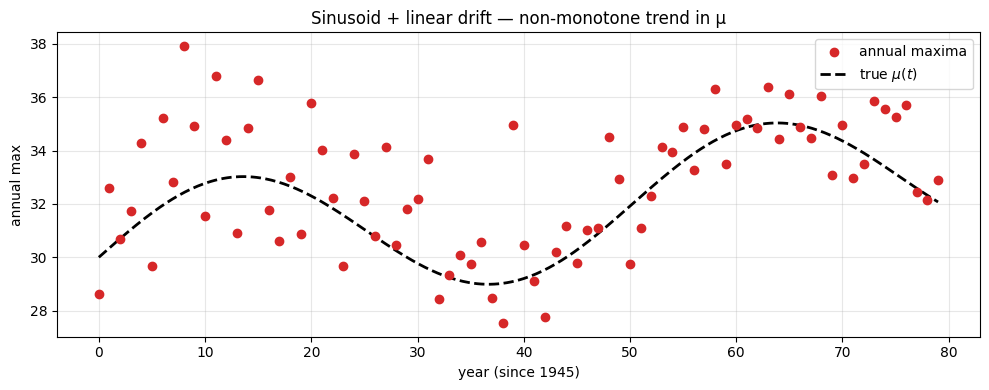

In [4]:
N_YEARS = 80
DAYS_PER_YEAR = 365
RNG = np.random.default_rng(20260429)

SIGMA_TRUE = 1.5
XI_TRUE = -0.10


def true_mu(t):
    """Sinusoid + linear drift in years t."""
    return 30.0 + 2.5 * np.sin(t / 8.0) + 0.04 * t


dates = pd.date_range("1945-01-01", periods=N_YEARS * DAYS_PER_YEAR, freq="D")
n = N_YEARS * DAYS_PER_YEAR
day_of_year = (dates.dayofyear - 1).to_numpy()
year_idx_daily = np.arange(n) / DAYS_PER_YEAR

# Build a parent process whose annual maxima follow a GEVD with the planted μ.
# Easier to simulate annual maxima directly.
t_year_np = np.arange(N_YEARS, dtype=float)
mu_t_truth = true_mu(t_year_np)
true_gev = GeneralizedExtremeValueDistribution(
    loc=jnp.asarray(mu_t_truth),
    scale=SIGMA_TRUE,
    concentration=XI_TRUE,
)
maxima = np.asarray(true_gev.sample(jax.random.PRNGKey(20260429), sample_shape=()))
t_year = jnp.asarray(t_year_np, dtype=jnp.float32)
maxima_jx = jnp.asarray(maxima, dtype=jnp.float32)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(t_year_np, maxima, color="tab:red", label="annual maxima", zorder=3)
t_dense = np.linspace(0, N_YEARS - 1, 400)
ax.plot(t_dense, true_mu(t_dense), color="black", lw=2, ls="--", label=r"true $\mu(t)$")
ax.set_xlabel("year (since 1945)")
ax.set_ylabel("annual max")
ax.set_title("Sinusoid + linear drift — non-monotone trend in μ")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Model: a 1-state neural ODE for μ(t)

We build a tiny MLP for the vector field $f_\theta(\mu, t)$:

- **Input:** the current state $\mu \in \mathbb{R}$ and the current time $t \in \mathbb{R}$ — concatenated to a 2-vector.
- **Hidden layers:** two layers of 16 units each, $\tanh$ activation.
- **Output:** $d\mu/dt \in \mathbb{R}$.

The total parameter count is $(2 \cdot 16 + 16) + (16 \cdot 16 + 16) + (16 \cdot 1 + 1) = 305$, plus the initial condition $\mu_0$ and the stationary $(\sigma, \xi)$ — about as parsimonious as a neural ODE gets.

In [5]:
class VectorField(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, key):
        self.mlp = eqx.nn.MLP(
            in_size=2,
            out_size=1,
            width_size=16,
            depth=2,
            activation=jax.nn.tanh,
            key=key,
        )

    def __call__(self, t, mu, args):
        # Normalise t to [-1, 1] so the MLP sees standardised inputs.
        t_norm = (2.0 * t / float(N_YEARS)) - 1.0
        x = jnp.array([mu.reshape(()), t_norm])
        return self.mlp(x).reshape(())


class NeuralODEModel(eqx.Module):
    vf: VectorField
    mu0: jax.Array
    log_sigma: jax.Array
    xi: jax.Array

    def __init__(self, key, mu0_init=30.0, sigma_init=2.0, xi_init=-0.05):
        self.vf = VectorField(key)
        self.mu0 = jnp.asarray(mu0_init)
        self.log_sigma = jnp.log(jnp.asarray(sigma_init))
        self.xi = jnp.asarray(xi_init)

    def mu_trajectory(self, t_save):
        """Solve the ODE from t=-1 to t=N_YEARS and save at t_save."""

        def rhs(t, mu, args):
            return self.vf(t, mu, args)

        sol = diffrax.diffeqsolve(
            terms=diffrax.ODETerm(rhs),
            solver=diffrax.Tsit5(),
            t0=-1.0,
            t1=float(N_YEARS),
            dt0=0.5,
            y0=self.mu0,
            saveat=diffrax.SaveAt(ts=t_save),
            stepsize_controller=diffrax.PIDController(rtol=1e-5, atol=1e-7),
            adjoint=diffrax.RecursiveCheckpointAdjoint(),
            max_steps=10_000,
        )
        return sol.ys

    def log_likelihood(self, t_save, maxima):
        mu_t = self.mu_trajectory(t_save)
        sigma = jnp.exp(self.log_sigma)
        gev = GeneralizedExtremeValueDistribution(
            loc=mu_t,
            scale=sigma,
            concentration=self.xi,
        )
        return jnp.sum(gev.log_prob(maxima))


model_key, _ = jax.random.split(KEY)
model = NeuralODEModel(model_key, mu0_init=float(maxima[0]))
print(
    f"Number of parameters: "
    f"{sum(p.size for p in jax.tree.leaves(eqx.filter(model, eqx.is_array)))}"
)
print(
    f"Initial μ_0 = {float(model.mu0):.3f}, σ = {float(jnp.exp(model.log_sigma)):.3f}, "
    f"ξ = {float(model.xi):.3f}"
)
print(f"Initial NLL: {-float(model.log_likelihood(t_year, maxima_jx)):.2f}")

Number of parameters: 340
Initial μ_0 = 28.617, σ = 2.000, ξ = -0.050


Initial NLL: 342.62


## 4. Training loop with optax.adam

step  500  NLL=  181.95  σ=2.112  ξ=-0.030


step 1000  NLL=  172.11  σ=1.958  ξ=-0.078


step 1500  NLL=  159.92  σ=1.699  ξ=-0.119


step 2000  NLL=  157.71  σ=1.641  ξ=-0.121

Final: σ = 1.641 (true 1.50)
       ξ = -0.121 (true -0.10)


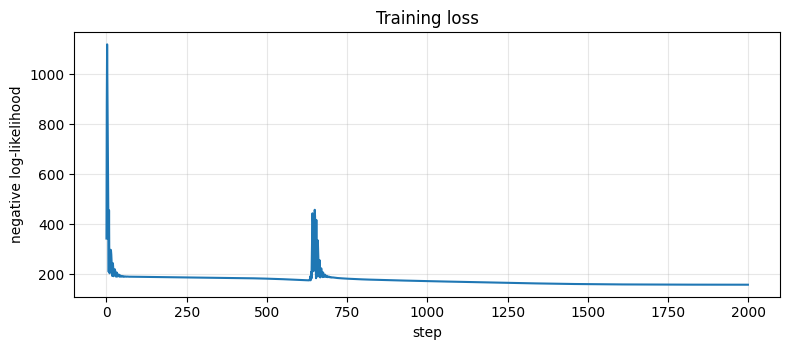

In [6]:
@eqx.filter_jit
def loss_and_grads(model, t_save, maxima):
    return eqx.filter_value_and_grad(lambda m: -m.log_likelihood(t_save, maxima))(model)


N_STEPS = 2000
schedule = optax.cosine_decay_schedule(
    init_value=1e-2,
    decay_steps=N_STEPS,
    alpha=0.01,
)
optimizer = optax.adam(learning_rate=schedule)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


@eqx.filter_jit
def step(model, opt_state, t_save, maxima):
    loss, grads = loss_and_grads(model, t_save, maxima)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


losses = []
for s in range(N_STEPS):
    model, opt_state, loss = step(model, opt_state, t_year, maxima_jx)
    losses.append(float(loss))
    if (s + 1) % 500 == 0:
        print(
            f"step {s + 1:4d}  NLL={float(loss):8.2f}  "
            f"σ={float(jnp.exp(model.log_sigma)):.3f}  "
            f"ξ={float(model.xi):.3f}"
        )

print(f"\nFinal: σ = {float(jnp.exp(model.log_sigma)):.3f} (true {SIGMA_TRUE:.2f})")
print(f"       ξ = {float(model.xi):.3f} (true {XI_TRUE:.2f})")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(losses, color="tab:blue")
ax.set_xlabel("step")
ax.set_ylabel("negative log-likelihood")
ax.set_title("Training loss")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Recovery of μ(t) from the trained ODE

Plot the integrated trajectory of the learned ODE on a dense time grid and overlay the truth.

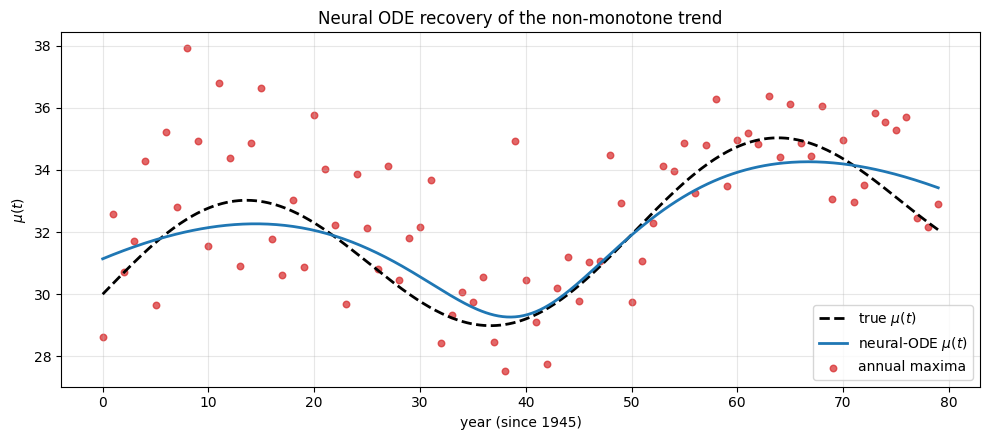

In [7]:
t_dense_jx = jnp.asarray(t_dense, dtype=jnp.float32)
mu_dense = np.asarray(model.mu_trajectory(t_dense_jx))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t_dense, true_mu(t_dense), color="black", lw=2, ls="--", label=r"true $\mu(t)$")
ax.plot(t_dense, mu_dense, color="tab:blue", lw=2, label=r"neural-ODE $\mu(t)$")
ax.scatter(t_year_np, maxima, color="tab:red", s=22, alpha=0.7, label="annual maxima")
ax.set_xlabel("year (since 1945)")
ax.set_ylabel(r"$\mu(t)$")
ax.set_title("Neural ODE recovery of the non-monotone trend")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Comparing against the linear and stationary fits

Compute the same MLE point estimates for the simpler models so we can put all three on one axis.

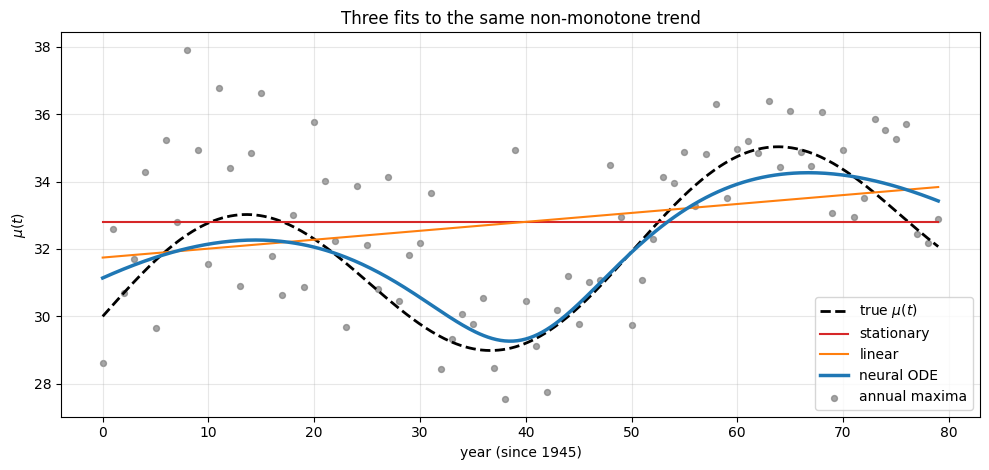

In [8]:
def stationary_mu_mle(maxima):
    return float(jnp.mean(maxima))


def linear_mle(maxima, t_train, t_eval):
    """Crude least-squares trend (proxy for the linear-GEVD posterior median)."""
    A = np.column_stack([np.ones_like(t_train), t_train])
    coef, *_ = np.linalg.lstsq(A, np.asarray(maxima), rcond=None)
    return coef[0] + coef[1] * np.asarray(t_eval)


mu_const = np.full_like(t_dense, stationary_mu_mle(maxima_jx))
mu_lin = linear_mle(maxima_jx, t_year_np, t_dense)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(t_dense, true_mu(t_dense), color="black", lw=2, ls="--", label=r"true $\mu(t)$")
ax.plot(t_dense, mu_const, color="tab:red", lw=1.5, label="stationary")
ax.plot(t_dense, mu_lin, color="tab:orange", lw=1.5, label="linear")
ax.plot(t_dense, mu_dense, color="tab:blue", lw=2.5, label="neural ODE")
ax.scatter(t_year_np, maxima, color="tab:gray", s=18, alpha=0.7, label="annual maxima")
ax.set_xlabel("year (since 1945)")
ax.set_ylabel(r"$\mu(t)$")
ax.set_title("Three fits to the same non-monotone trend")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Reading this.** The constant fit and the linear fit cannot represent the oscillation; the neural ODE picks up both the slow drift and the sinusoidal component. The drift alone over 80 years is $0.04 \times 80 = 3.2$ — about $1\sigma$ of the noise — so the linear fit gets it right *on average* but consistently mispredicts in any given decade.

## 7. Time-varying return-level curve

As before, with $\mu(t)$ in hand and stationary $(\sigma, \xi)$, the year-$T$ return level is just $\mu(t)$ + a constant excess. We use the trained $\sigma, \xi$ for a point-estimate band; a Bayesian version would put priors on $\theta, \mu_0, \sigma, \xi$ jointly and run NUTS through `diffrax`, but that's a heavier lift than this notebook needs.

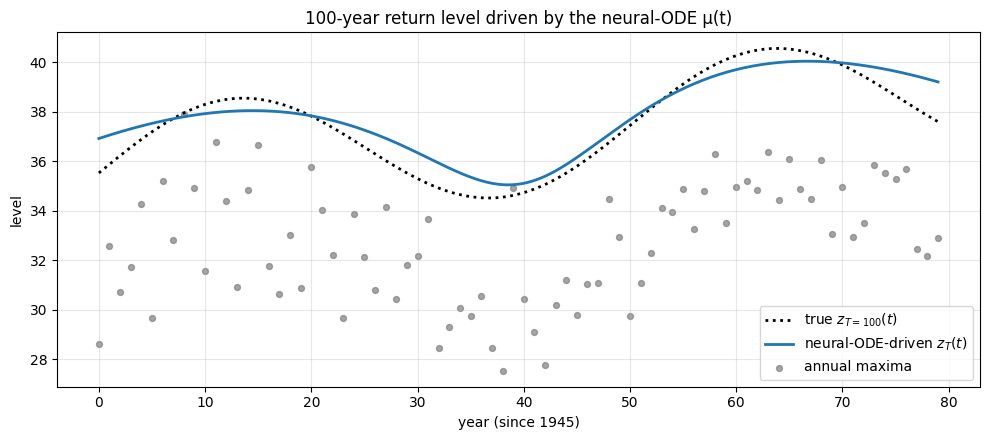

In [9]:
T = 100.0
sigma_est = float(jnp.exp(model.log_sigma))
xi_est = float(model.xi)


def excess_at_T(sigma, xi, T_):
    if abs(xi) < 1e-7:
        return -sigma * np.log(-np.log(1.0 - 1.0 / T_))
    return (sigma / xi) * (np.power(-np.log(1.0 - 1.0 / T_), -xi) - 1.0)


excess_T_est = excess_at_T(sigma_est, xi_est, T)
excess_T_truth = excess_at_T(SIGMA_TRUE, XI_TRUE, T)

zT_est = mu_dense + excess_T_est
zT_truth = true_mu(t_dense) + excess_T_truth

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(
    t_dense, zT_truth, color="black", lw=2, ls=":", label=rf"true $z_{{T={T:.0f}}}(t)$"
)
ax.plot(t_dense, zT_est, color="tab:blue", lw=2, label="neural-ODE-driven $z_T(t)$")
ax.scatter(t_year_np, maxima, color="tab:gray", s=18, alpha=0.7, label="annual maxima")
ax.set_xlabel("year (since 1945)")
ax.set_ylabel("level")
ax.set_title("100-year return level driven by the neural-ODE μ(t)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 8. The vector field as a phase portrait

Because $f_\theta(\mu, t)$ takes both the state and time, the *phase portrait* is 2D: arrows on the $(\mu, t)$ plane. Plotting it shows the structure the network has learned — where $d\mu/dt$ is large vs small, positive vs negative.

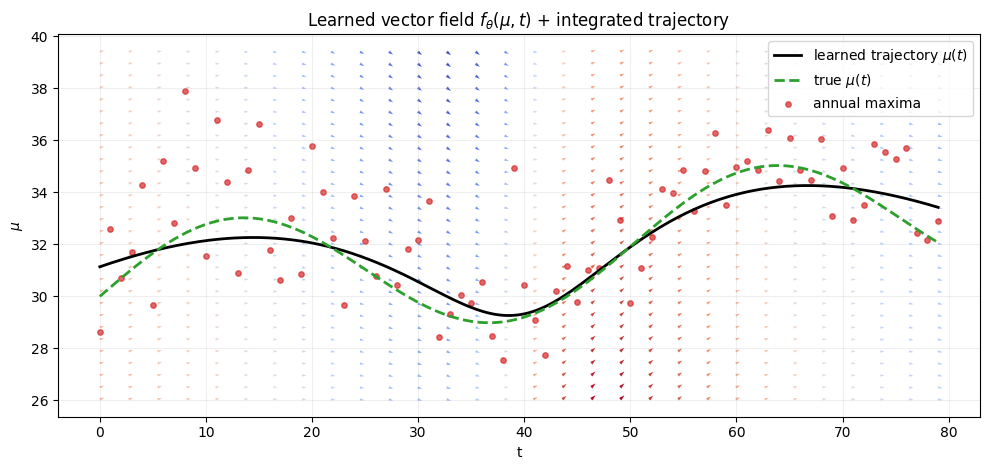

In [10]:
mu_grid = np.linspace(maxima.min() - 1.5, maxima.max() + 1.5, 30)
t_grid_pp = np.linspace(0, N_YEARS - 1, 30)
M, T_ = np.meshgrid(mu_grid, t_grid_pp, indexing="xy")


@jax.vmap
def vf_eval(t_v, mu_v):
    return model.vf(t_v, mu_v, None)


flow = np.asarray(vf_eval(jnp.asarray(T_.ravel()), jnp.asarray(M.ravel())))
flow = flow.reshape(M.shape)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.quiver(
    T_,
    M,
    np.ones_like(flow),
    flow,
    flow,
    cmap="coolwarm",
    angles="xy",
    scale_units="xy",
    scale=2.5,
    width=0.0025,
)
ax.plot(t_dense, mu_dense, color="black", lw=2, label=r"learned trajectory $\mu(t)$")
ax.plot(
    t_dense, true_mu(t_dense), color="tab:green", lw=2, ls="--", label=r"true $\mu(t)$"
)
ax.scatter(t_year_np, maxima, color="tab:red", s=15, alpha=0.7, label="annual maxima")
ax.set_xlabel("t")
ax.set_ylabel(r"$\mu$")
ax.set_title(r"Learned vector field $f_\theta(\mu, t)$ + integrated trajectory")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

- **Neural ODEs are a flexible, dynamical-systems-flavoured way to parameterise a non-stationary GEVD location.** The state $\mu(t)$ is the integral of a learned vector field; gradients flow through `diffrax.diffeqsolve`.
- **Smoothness comes for free.** A $C^1$ vector field gives a $C^1$ trajectory — no smoothness penalty needed, no knot placement.
- **The cost is identifiability and interpretability.** A 305-parameter MLP is much harder to inspect than a 12-coefficient spline; with the small dataset here, many vector-field configurations are observationally equivalent.
- **Use cases.** Multi-dimensional latent state (multiple coupled extremes), control inputs (forcings), or any setting where a *causal mechanism* is more appropriate than a basis expansion.
- **Bayesian extension.** Replace `optax.adam` with NumPyro NUTS over the same parameters and you get a fully Bayesian neural-ODE-driven GEVD. The ODE solver is differentiable so HMC works through it; expect long compile times and many divergences without careful prior choice and re-parameterisation.

This concludes the three-notebook non-stationary mini-series:

1. **Parametric** — linear $\mu(t) = \beta_0 + \beta_1 t$.
2. **Non-parametric basis expansion** — P-splines.
3. **Dynamical** — neural ODE.

Each successive notebook is more flexible and more parameter-hungry; each takes the same shape of "fit $\mu(\cdot)$, leave $(\sigma, \xi)$ stationary". The right choice for any particular dataset is a function of *how much data you have* and *whether the domain motivates a mechanistic model*.